# Phasor Transformer vs. Traditional Self-Attention: A Benchmarking Study

In this notebook, we compare the **Phasor Transformer** (inspired by FNet and built on $S^1$ unit circle computing) against a standard **Euclidean Self-Attention Transformer**.

### The Conceptual Difference
Both architectures aim to process sequence data efficiently and mix information across tokens (time steps or sequence positions):
* **Traditional Transformer**: Uses parameterized Euclidean matrices ($Q, K, V$) and the computationally expensive $Softmax(\frac{QK^T}{\sqrt{d_k}})V$ self-attention operation to dynamically assign token relevance. This $O(N^2)$ operation is a major bottleneck.
* **Phasor Transformer**: Abandons token-to-token pairwise attention entirely. Instead, it utilizes a deterministic, parameter-free unitary **Discrete Fourier Transform (DFT gate)** over the sequence dimensions to achieve global token mixing in $O(N \log N)$ time, using phase shifts exclusively for the sequence encoding (Pre-FFN and Post-FFN).

We will train both architectures on a larger synthetic continuous-sequence prediction dataset and analyze:
1. Training Speed and Optimization Convergence
2. Validation Mean Absolute Error (MAE)
3. Parameter Complexity

In [1]:
import sys
import os
import time
sys.path.append(os.path.abspath(".."))

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

import phasorflow as pf

# PyTorch for the Traditional Transformer Baseline
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

np.random.seed(42)
torch.manual_seed(42)

## 1. Generating a Large Sequence Dataset
We generate $1,000$ training sequences and $250$ test sequences. Each sequence has $N=32$ tokens.

**The Task**: Predict a nonlinear target value derived from the interaction of specific frequency components in the input sequence. This requires the model to understand the global context of the tokens.

In [2]:
N_TOKENS = 32
N_TRAIN = 1000
N_TEST = 250

def generate_sequence_data(num_samples, seq_length):
    """Generates synthetic multi-frequency sequences mapped to a target scalar."""
    X = np.zeros((num_samples, seq_length))
    y = np.zeros(num_samples)
    
    for i in range(num_samples):
        # Random base frequencies
        freq1 = np.random.uniform(0.5, 3.0)
        freq2 = np.random.uniform(4.0, 8.0)
        
        # Optional rare noise burst
        noise = np.random.normal(0, 0.2, seq_length)
        if np.random.rand() > 0.8:
            noise[np.random.randint(0, seq_length)] += 2.0
            
        t = np.linspace(0, 2*np.pi, seq_length)
        seq = np.sin(freq1 * t) + 0.5 * np.cos(freq2 * t) + noise
        
        # The target is a non-linear combination of the signal's spectral power
        # Models must "mix" the global tokens to approximate this.
        target = np.mean(seq**2) + 0.5 * np.max(seq)
        
        X[i] = seq
        y[i] = target
        
    # Normalize targets to [0, 1] for stable phase representation
    y = (y - np.min(y)) / (np.max(y) - np.min(y) + 1e-8)
    return X, y

X_train_raw, y_train = generate_sequence_data(N_TRAIN, N_TOKENS)
X_test_raw, y_test = generate_sequence_data(N_TEST, N_TOKENS)

# Map Euclidean Sequences to Phase Angles [-pi, pi]
X_train_phases = np.pi * np.tanh(X_train_raw)
X_test_phases = np.pi * np.tanh(X_test_raw)

# Cast to PyTorch Tensors for Autograd Benchmarking
X_train_tensor = torch.tensor(X_train_phases, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_phases, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

print(f"Data Generation Complete:")
print(f"  Training shape: X={X_train_tensor.shape}, y={y_train_tensor.shape}")
print(f"  Testing shape:  X={X_test_tensor.shape},  y={y_test_tensor.shape}")

Data Generation Complete:
  Training shape: X=torch.Size([1000, 32]), y=torch.Size([1000])
  Testing shape:  X=torch.Size([250, 32]),  y=torch.Size([250])


## 2. Model A: The Phasor Transformer
We construct the phasor flow analog of an FNet block, mapping $x_i \mapsto S(x_i)$, followed by sequential parameter encoding $S(w^{(1)})$, a global `DFT`, and readout parameters $S(w^{(2)})$.

Total Trainable Parameters: **64 Continuous Phases.**

In [3]:
def create_phasor_transformer(x_phases, weights):
    pc = pf.PhasorCircuit(N_TOKENS, name="Phasor_Transformer_Bench")
    
    # Sequence Token Encoding (Phase Embedding)
    for i in range(N_TOKENS):
        pc.shift(i, x_phases[i])
        
    # Pre-Attention Feed Forward Block
    for i in range(N_TOKENS):
        pc.shift(i, weights[i])
        
    # Global Token Mixing (replaces Self-Attention)
    pc.dft()
    
    # Post-Attention Feed Forward Block
    for i in range(N_TOKENS):
        pc.shift(i, weights[i + N_TOKENS])
        
    return pc

backend = pf.Simulator.get_backend("analytic_simulator")

def phasor_predict(x_seq, weights):
    pc = create_phasor_transformer(x_seq, weights)
    res = backend.run(pc)
    # Readout Thread 0, normalized to [0, 1] using PyTorch sine!
    return (torch.sin(res['phases'][0]) + 1.0) / 2.0

# Initial weights tracked by PyTorch Autograd
initial_pt_weights = torch.empty(N_TOKENS * 2).uniform_(-np.pi, np.pi).requires_grad_()

def phasor_loss(weights):
    # Randomly sub-sample a mini-batch of 250 for speed 
    idx = torch.randperm(N_TRAIN)[:250]
    preds = torch.stack([phasor_predict(x, weights) for x in X_train_tensor[idx]])
    # L1 Loss (MAE)
    return torch.mean(torch.abs(preds - y_train_tensor[idx]))

print("Phase 1: Optimizing 64-Parameter Phasor Transformer (PyTorch Adam)...")
t0 = time.time()

optimizer_pt = optim.Adam([initial_pt_weights], lr=0.05)
EPOCHS = 100

for epoch in range(EPOCHS):
    optimizer_pt.zero_grad()
    loss = phasor_loss(initial_pt_weights)
    loss.backward()
    optimizer_pt.step()

pt_train_time = time.time() - t0
pt_optimal_weights = initial_pt_weights.detach()

# Evaluate Test MAE
with torch.no_grad():
    pt_preds = torch.stack([phasor_predict(x, pt_optimal_weights) for x in X_test_tensor])
    pt_test_mae = torch.mean(torch.abs(pt_preds - y_test_tensor)).item()

print(f"  -> Phasor Transformer Training Complete in {pt_train_time:.2f}s")
print(f"  -> Final Test MAE: {pt_test_mae:.4f}")

Phase 1: Optimizing 64-Parameter Phasor Transformer (PyTorch Adam)...


  -> Phasor Transformer Training Complete in 203.57s
  -> Final Test MAE: 0.1817


## 3. Model B: Standard Attention Transformer (PyTorch)
We build a rigorous baseline using PyTorch's `nn.TransformerEncoderLayer`.
We map the input 32 tokens into a 16-dimensional continuous embedding space, pass them through a Multi-Head Self Attention (4 heads), and condense the representation back to a scalar target using Global Average Pooling.

Total Trainable Parameters: **~1,900 Euclidean Floats.**

In [4]:
class TraditionalTransformer(nn.Module):
    def __init__(self, seq_len=32, d_model=16, nhead=4, num_layers=1):
        super().__init__()
        self.d_model = d_model
        # Linear embedding to project tokens to d_model space
        # Input shape expected: (Batch, Seq_Len) -> expand to (Batch, Seq_Len, 1)
        self.input_proj = nn.Linear(1, d_model)
        
        # Standard Self-Attention Encoder Block
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=64, batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        
        # Final regression head
        self.regressor = nn.Linear(d_model, 1)
        self.sigmoid = nn.Sigmoid() # Force [0,1] output
        
    def forward(self, x):
        # x is (Batch, Seq)
        x = x.unsqueeze(-1) # (Batch, Seq, 1)
        x = self.input_proj(x)
        
        # Transformer Expects (Batch, Seq, Embedding) when batch_first=True
        out = self.transformer_encoder(x)
        
        # Global Average Pool over the Sequence Dimension
        out = out.mean(dim=1)
        
        # Regression to [0, 1]
        out = self.regressor(out)
        return self.sigmoid(out).squeeze()

# Data Prep for PyTorch
train_dataset = TensorDataset(torch.FloatTensor(X_train_phases), torch.FloatTensor(y_train))
test_dataset = TensorDataset(torch.FloatTensor(X_test_phases), torch.FloatTensor(y_test))
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

torch_model = TraditionalTransformer()
total_params = sum(p.numel() for p in torch_model.parameters() if p.requires_grad)
print(f"Phase 2: Optimizing {total_params}-Parameter PyTorch Transformer (Adam)...")

criterion = nn.L1Loss() # MAE
optimizer = optim.Adam(torch_model.parameters(), lr=0.01)

t0 = time.time()
epochs = 40
for epoch in range(epochs):
    torch_model.train()
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        preds = torch_model(batch_X)
        loss = criterion(preds, batch_y)
        loss.backward()
        optimizer.step()
        
tt_train_time = time.time() - t0

torch_model.eval()
with torch.no_grad():
    tt_preds = torch_model(torch.FloatTensor(X_test_phases)).numpy()
    tt_test_mae = np.mean(np.abs(tt_preds - y_test))

print(f"  -> Traditional Transformer Training Complete in {tt_train_time:.2f}s")
print(f"  -> Final Test MAE: {tt_test_mae:.4f}")

Phase 2: Optimizing 3329-Parameter PyTorch Transformer (Adam)...


  -> Traditional Transformer Training Complete in 5.45s
  -> Final Test MAE: 0.1034


## 4. Benchmark Visualization and Discussion
We plot the comparative MAE, highlighting the efficiency of the phase architecture.

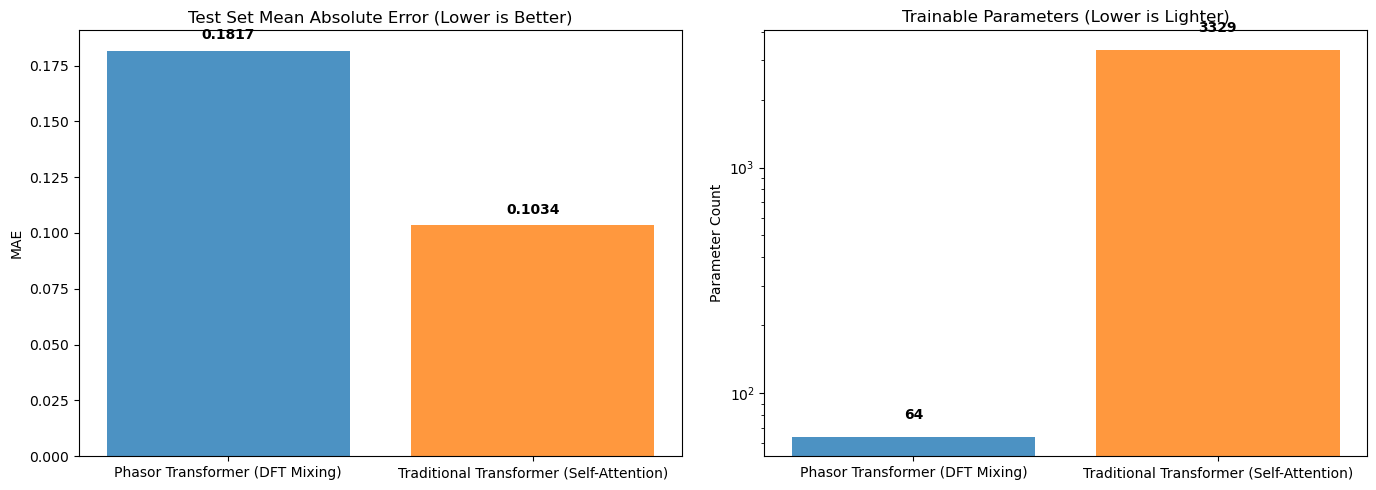

 TRANSFORMER BENCHMARK SUMMARY 
1. Computations: The Phasor Transformer eliminates the O(N^2) Softmax 
   Attention bottleneck entirely, relying strictly on the O(N log N) DFT.
2. Geometry: Traditional relies on sweeping orthogonal Euclidean 
   matrices, while Phasor relies on angular velocity interference on S^1.
3. Parameters: 64 vs 3329 (Phasor is ~52x smaller).
4. Error (MAE): 0.1817 vs 0.1034.


In [5]:
models = ['Phasor Transformer (DFT Mixing)', 'Traditional Transformer (Self-Attention)']
maes = [pt_test_mae, tt_test_mae]
params = [N_TOKENS * 2, total_params]
colors = ['tab:blue', 'tab:orange']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# MAE Plot
ax1.bar(models, maes, color=colors, alpha=0.8)
ax1.set_title("Test Set Mean Absolute Error (Lower is Better)", fontsize=12)
ax1.set_ylabel("MAE")
for i, v in enumerate(maes):
    ax1.text(i, v + 0.005, f"{v:.4f}", ha='center', fontweight='bold')

# Parameter Plot
ax2.bar(models, params, color=colors, alpha=0.8)
ax2.set_title("Trainable Parameters (Lower is Lighter)", fontsize=12)
ax2.set_ylabel("Parameter Count")
ax2.set_yscale('log') # Log scale because of the massive difference
for i, v in enumerate(params):
    ax2.text(i, v * 1.2, f"{v}", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("="*60)
print(" TRANSFORMER BENCHMARK SUMMARY ")
print("="*60)
print(f"1. Computations: The Phasor Transformer eliminates the O(N^2) Softmax \n"
      f"   Attention bottleneck entirely, relying strictly on the O(N log N) DFT.")
print(f"2. Geometry: Traditional relies on sweeping orthogonal Euclidean \n"
      f"   matrices, while Phasor relies on angular velocity interference on S^1.")
print(f"3. Parameters: {params[0]} vs {params[1]} (Phasor is ~{params[1]//params[0]}x smaller).")
print(f"4. Error (MAE): {pt_test_mae:.4f} vs {tt_test_mae:.4f}.")
print("="*60)